# KI

In [62]:
# Imports

import pandas as pd
import os

import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import plot_tree
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import pickle
import os

In [63]:
# Configs

# Daten
base_path = os.path.abspath(os.path.join(os.getcwd(), '../../data/messung_08_01_26'))
files = [
    'sand_training_data.csv',
    'gravel_training_data.csv',
    'stones_training_data.csv'
]

# Model
MAX_DEPTH = 4
save_model = False
model_save_path = os.path.abspath(os.path.join(os.getcwd(), "../../models/sonar_model_v2.pkl"))




## Trainingsdaten laden

In [64]:

# Daten einlesen
data_frames = []
for file in files:
    file_path = os.path.join(base_path, file)
    df = pd.read_csv(file_path, sep=';')                # Einlesen der CSV-Dateien, Trennzeichen ist Semikolon
    data_frames.append(df)

# Zusammenfügen zu einem einzigen DataFrame
full_df = pd.concat(data_frames, ignore_index=True)

# Filtern der Spalten: Wir wollen 'class_name', 'Frequency' und alle 'S_...' Spalten
amplitude_cols = [col for col in full_df.columns if col.startswith('S_')]               # Identifizieren der Spalten, die mit 'S_' beginnen
selected_cols = ['class_name', 'Frequency'] + amplitude_cols                        # Auswahl der gewünschten Spalten
final_df = full_df[selected_cols]

# Anzeigen der ersten Zeilen und der Größe des DataFrames
print(f"Form des DataFrames: {final_df.shape}")
display(final_df.head())

Form des DataFrames: (108, 402)


,class_name,Frequency,S_0,S_1,S_2,S_3,S_4,S_5,S_6,S_7,...,S_390,S_391,S_392,S_393,S_394,S_395,S_396,S_397,S_398,S_399
0,Sand,low,136,200,226,255,260,250,242,239,...,85.0,90.0,94.0,98.0,98.0,92.0,90.0,91.0,99.0,104.0
1,Sand,high,448,358,583,996,1002,1039,2206,3412,...,41.0,47.0,52.0,49.0,52.0,54.0,49.0,41.0,42.0,48.0
2,Sand,low,136,201,225,255,261,251,242,239,...,159.0,151.0,141.0,137.0,132.0,133.0,131.0,133.0,131.0,118.0
3,Sand,high,454,365,592,963,958,1200,2544,3785,...,43.0,33.0,26.0,21.0,21.0,21.0,22.0,23.0,22.0,19.0
4,Sand,low,136,201,228,256,261,251,243,239,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Ausgabe vo 20 Zeitreihen pro klasse in ein Diagramm

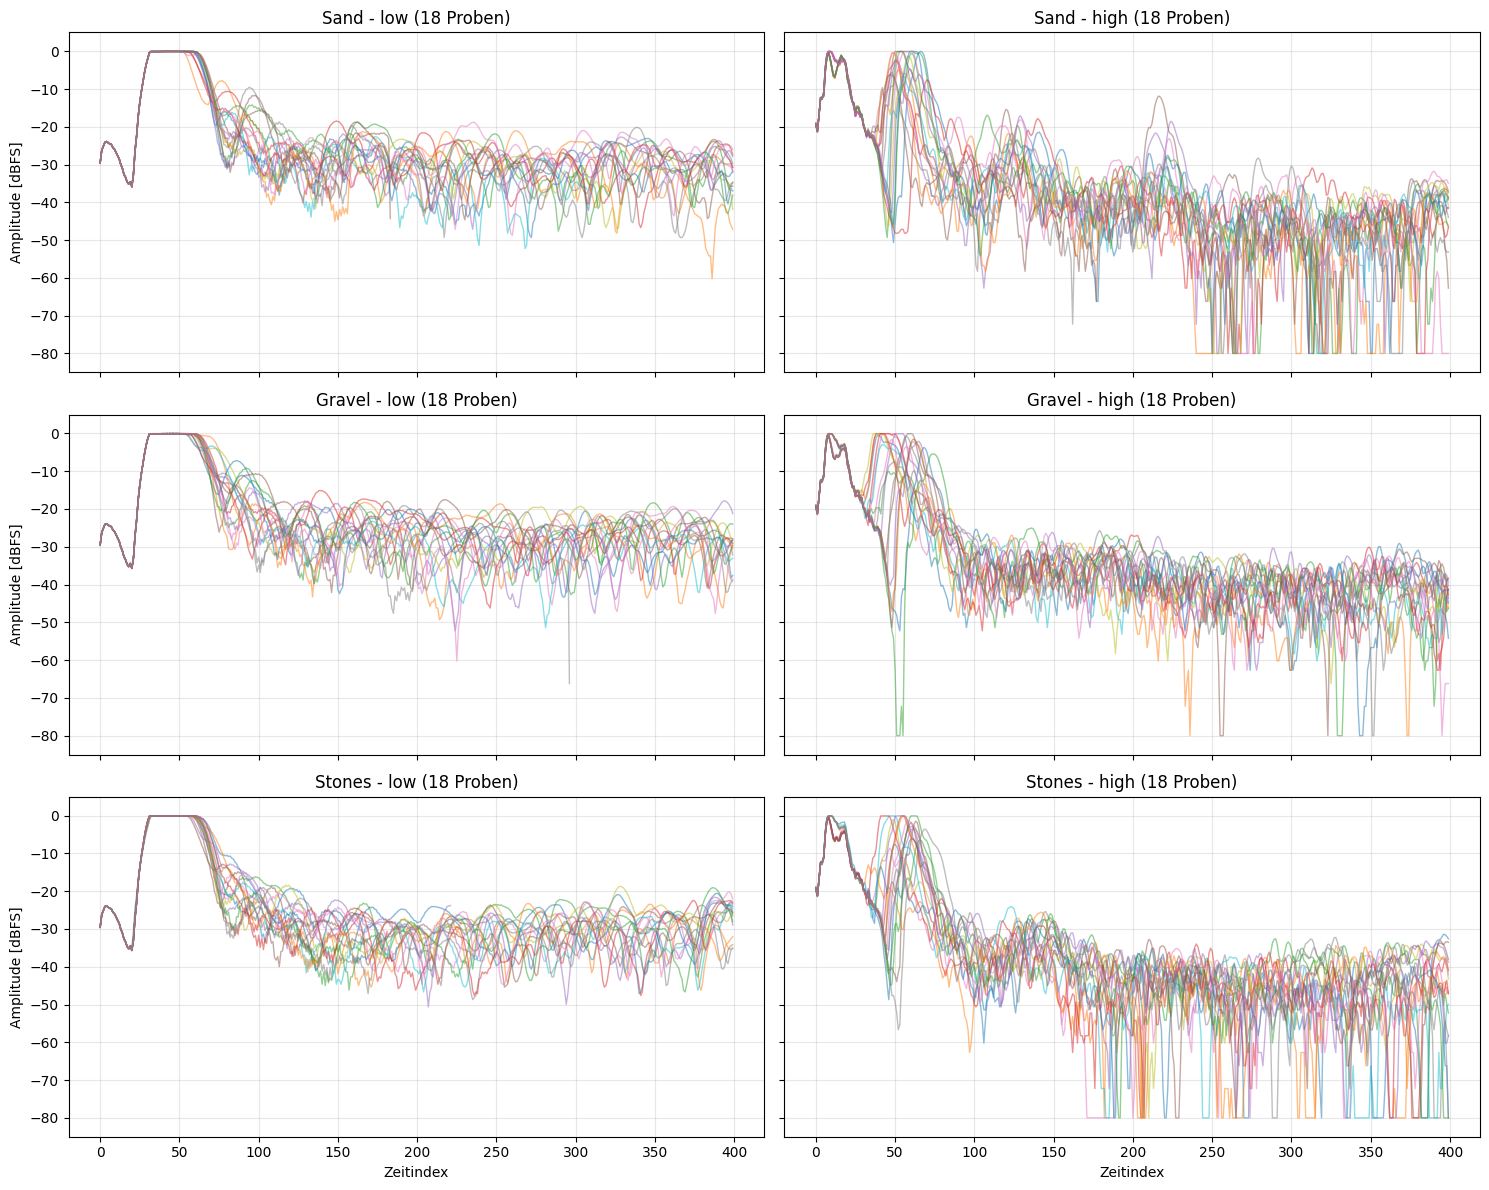

In [65]:
# Eindeutige Klassen finden
classes = ['Sand', 'Gravel', 'Stones']
frequencies = ['low', 'high']  # Definierte Reihenfolge

num_classes = len(classes)
num_freqs = len(frequencies)

# Subplots erstellen: Zeilen = Klassen, Spalten = Frequenzen
# sharey='row' sorgt dafür, dass die Y-Achsen innerhalb einer Klasse vergleichbar sind
fig, axes = plt.subplots(num_classes, num_freqs, figsize=(15, 4*num_classes), sharex=True, sharey='row')

# Wenn es nur eine Klasse gibt, ist axes ein 1D Array, wir machen es 2D für konsistente Indizierung
if num_classes == 1:
    axes = np.array([axes])

for i, class_name in enumerate(classes):
    for j, freq in enumerate(frequencies):
        ax = axes[i, j]
        
        # Daten filtern für spezifische Klasse und Frequenz
        subset = final_df[(final_df['class_name'] == class_name) & (final_df['Frequency'] == freq)]
        
        n_samples = min(20, len(subset))
        
        if n_samples > 0:
            # Zufällige Auswahl
            sampled_data = subset.sample(n_samples, random_state=42)
            
            # --- START ÄNDERUNG ---
            # 1. Rohdaten holen (als Float)
            result = sampled_data.drop(columns=['class_name', 'Frequency']).values.astype(float)
            
            # 2. Direkt in dB umrechnen (Vektiorisiert für alle Zeilen gleichzeitig)
            # Normalisieren (/4095), Logarithmieren (20*log10) und Clippen (min -80dB)
            amplitudes = np.clip(20 * np.log10(np.clip(result / 4095.0, 1e-9, 1.0)), -80, 0)
            
            # Plotten
            for row in amplitudes:
                ax.plot(row, alpha=0.5, linewidth=1)
                
            # Y-Achse fixieren (-85 bis 5 dB)
            ax.set_ylim(-85, 5)
            # --- ENDE ÄNDERUNG ---
            ax.set_title(f'{class_name} - {freq} ({n_samples} Proben)')
        else:
            ax.set_title(f'{class_name} - {freq} (Keine Daten)')
        
        ax.grid(True, alpha=0.3)
        
        # Y-Label nur in der ersten Spalte
        if j == 0:
            ax.set_ylabel('Amplitude [dBFS]')
        
        # X-Label nur in der letzten Zeile
        if i == num_classes - 1:
            ax.set_xlabel('Zeitindex')

plt.tight_layout()
plt.show()

## Algorithmus zur Klassifikation 


### Datenvorbereitung


In [66]:
df_model = final_df.copy()
df_model['Frequency_Code'] = df_model['Frequency'].map({'low': 0, 'high': 1})

# Features zusammenstellen: Amplituden + Frequenz-Code
amplitude_cols = [c for c in df_model.columns if c.startswith('S_')]
feature_cols = amplitude_cols + ['Frequency_Code']

X = df_model[feature_cols].values
y = df_model['class_name'].values

print(f"Feature Matrix Shape: {X.shape} (Samples x Features)")

# Labels in Zahlen umwandeln
le = LabelEncoder()
y_encoded = le.fit_transform(y)


Feature Matrix Shape: (108, 401) (Samples x Features)


### Trainieren

In [67]:
# Modell erstellen und evaluieren
clf = RandomForestClassifier(n_estimators=100, max_depth=MAX_DEPTH, random_state=42)

# Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, X, y_encoded, cv=cv, scoring='accuracy')

print(f"Cross-Validation Accuracy Scores: {scores}")
print(f"Cross-Validation Accuracy: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")


Cross-Validation Accuracy Scores: [0.77272727 0.81818182 0.77272727 0.85714286 0.85714286]
Cross-Validation Accuracy: 0.8156 (+/- 0.0755)


#### Speichern 

In [68]:
if save_model:
    # Ordner erstellen, falls er nicht existiert
    os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

    # Modell speichern
    with open(save_path, 'wb') as f:
        pickle.dump(clf, f)
    print(f"✅ Modell erfolgreich gespeichert: {model_save_path}")
else:
    print(f"Modell nicht gespeichert: {model_save_path}")
    

Modell nicht gespeichert: c:\Users\samso\Documents\00 Uni\Semester 9\sonar_mpa\models\sonar_model_v2.pkl


### Vorhersagen 

In [69]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=le.classes_))



Classification Report (Test Set):
              precision    recall  f1-score   support

      Gravel       0.86      0.86      0.86         7
        Sand       1.00      1.00      1.00         7
      Stones       0.88      0.88      0.88         8

    accuracy                           0.91        22
   macro avg       0.91      0.91      0.91        22
weighted avg       0.91      0.91      0.91        22



#### Bewertung

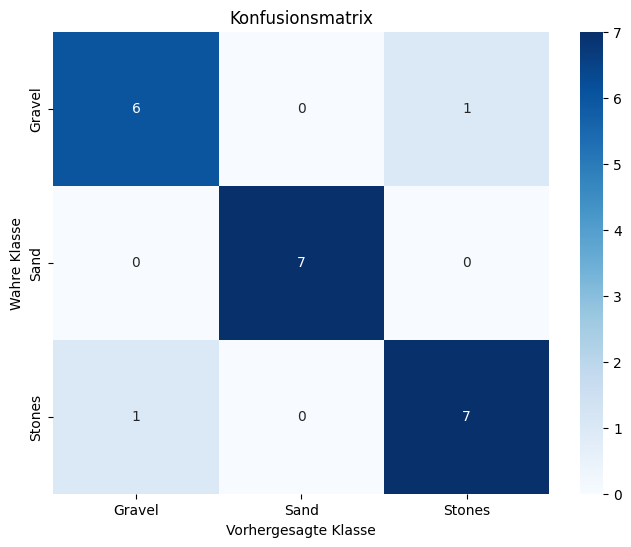

In [70]:
# A) Konfusionsmatrix

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.ylabel('Wahre Klasse')
plt.xlabel('Vorhergesagte Klasse')
plt.title('Konfusionsmatrix')
plt.show()


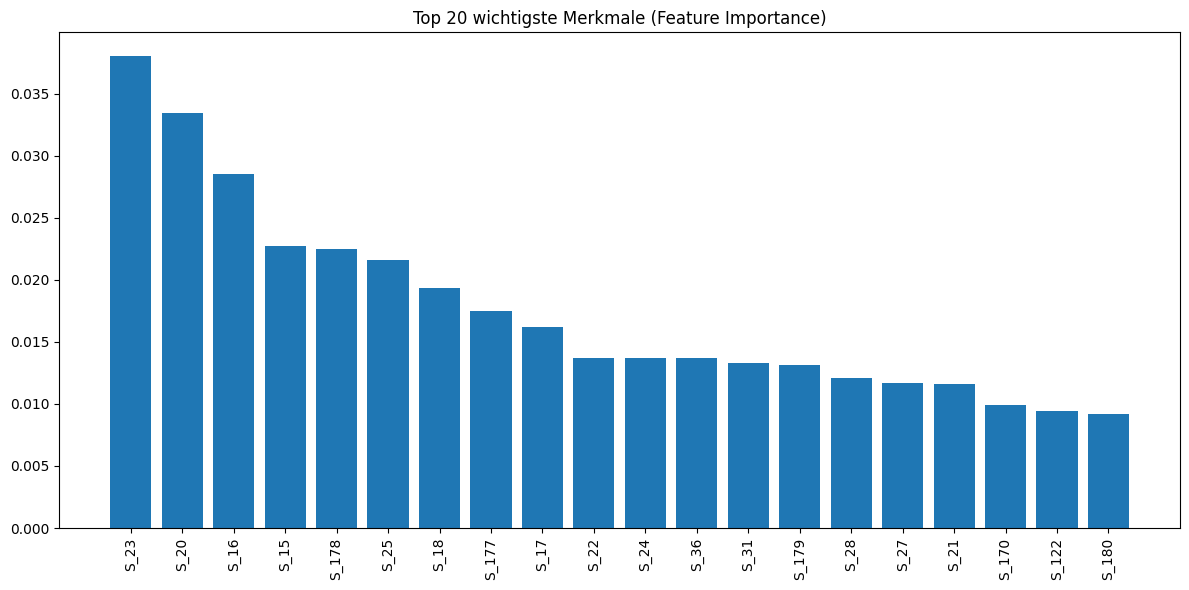


Wichtigkeit der Frequenz-Info: 0.0000


In [71]:
# B) Feature Importance (Was ist wichtig?)

importances = clf.feature_importances_
indices = np.argsort(importances)[::-1][:20] # Top 20

plt.figure(figsize=(12, 6))
plt.title("Top 20 wichtigste Merkmale (Feature Importance)")
plt.bar(range(20), importances[indices], align="center")
plt.xticks(range(20), [feature_cols[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

# Wichtigkeit der Frequenz explizit ausgeben
freq_idx = len(feature_cols) - 1
print(f"\nWichtigkeit der Frequenz-Info: {importances[freq_idx]:.4f}")


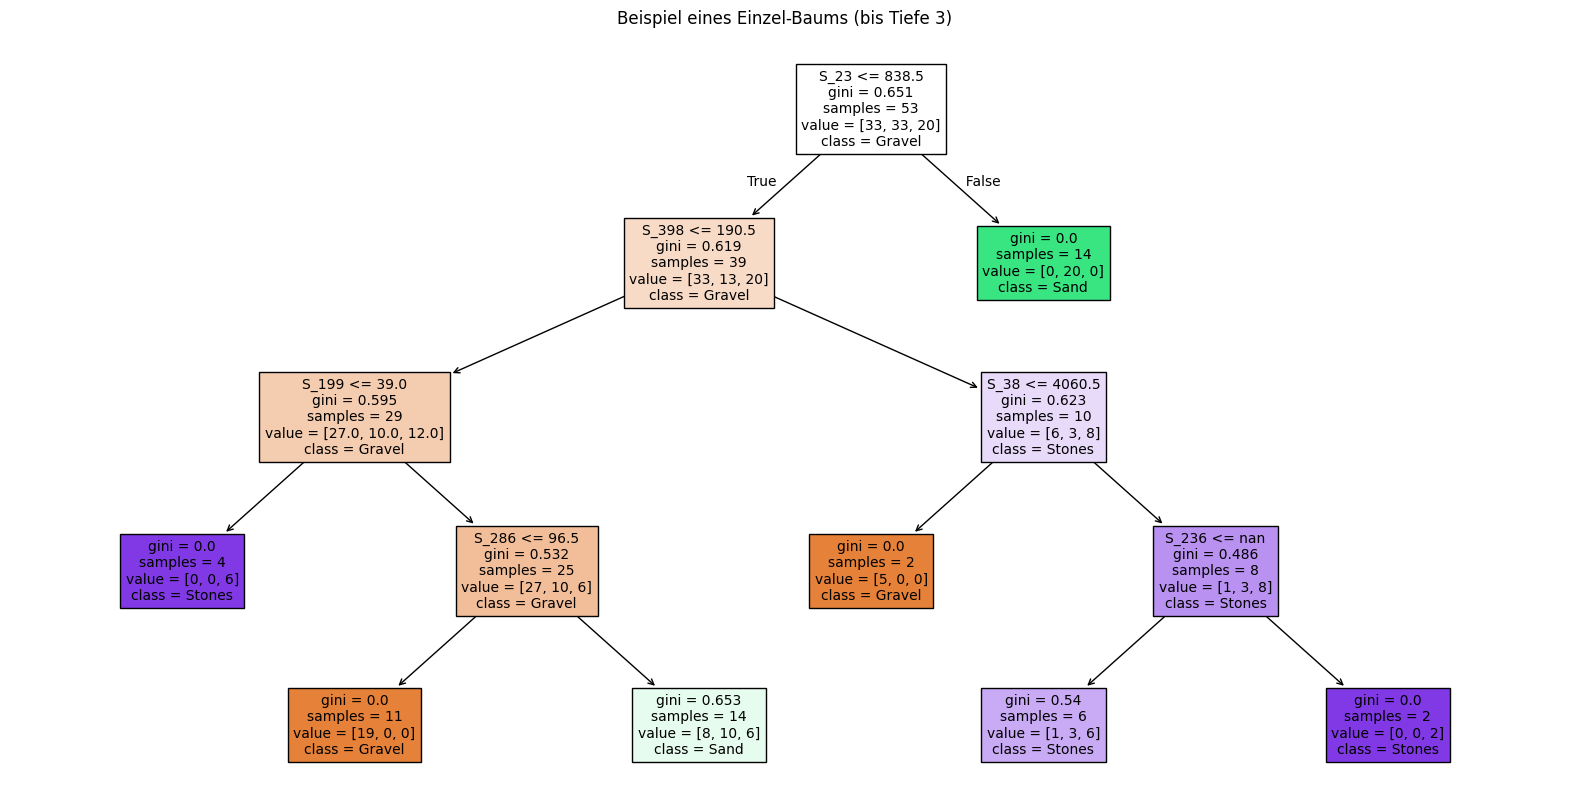

In [74]:
# C) Entscheidungsbaum visualisieren (Einer aus dem Wald)

plt.figure(figsize=(20, 10))
# Wir begrenzen die Tiefe in der Grafik, damit man noch etwas lesen kann
plot_tree(clf.estimators_[0], feature_names=feature_cols, class_names=le.classes_, filled=True, max_depth=MAX_DEPTH , fontsize=10)
plt.title("Beispiel eines Einzel-Baums (bis Tiefe 3)")
plt.show()